In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df = pd.read_csv('Louisville_Metro_KY_-_Library_Collection_Inventory_.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Louisville_Metro_KY_-_Library_Collection_Inventory_.csv'

In [ ]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1422972 non-null  float64
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 139.1+ MB


Changing ISBN dtype to 'string' as it is unchangeable and not useful for mathematical equations.

In [ ]:
df = df.astype({'ISBN':'object'})
df.dtypes

BibNum               int64
Title               object
Author              object
ISBN                object
PublicationYear      int64
ItemType            object
ItemCollection      object
ItemLocation        object
ItemPrice          float64
ReportDate          object
ObjectId             int64
dtype: object

In [ ]:
df['ISBN'] = df['ISBN'].astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1657555 non-null  object 
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 139.1+ MB


In [ ]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice', 'ReportDate',
       'ObjectId'],
      dtype='object')

Dropping 'ObjectId' and 'ReportDate' (if it is equal entries) as they are not necessary to answer questions I have about the data

In [ ]:
df.drop(['ObjectId'], axis=1, inplace =True)


In [ ]:
df['ReportDate'].unique()

array(['2022/07/01 04:00:00+00'], dtype=object)

In [ ]:
df.drop(['ReportDate'], axis=1, inplace=True)

In [ ]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice'],
      dtype='object')

In [ ]:
df.isna()

df.isna().sum()

BibNum                  0
Title                   1
Author             195724
ISBN                    0
PublicationYear         0
ItemType                0
ItemCollection        205
ItemLocation            0
ItemPrice               0
dtype: int64

In [ ]:
df.loc[df['Title'].isna()]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
243965,2239375,NaN,NaN,nan,0,Book,NaN,Crescent Hill,0.0


Dropping 'Title' == NaN as the row contains very little information and would not be helpful for data

In [ ]:
df = df.drop(243965)

In [ ]:
df.isna().sum()

BibNum                  0
Title                   0
Author             195723
ISBN                    0
PublicationYear         0
ItemType                0
ItemCollection        204
ItemLocation            0
ItemPrice               0
dtype: int64

In [ ]:
df.loc[df['ItemCollection'].isna()]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
8026,1353780,LANKIE MANTITA,LESLIE PATRICELLI,nan,0,Book,NaN,Shively,0.0
8587,2511351,My First Pet,NaN,nan,0,Book,NaN,Newburg,0.0
10501,1362079,Act of War,"Brown, Dale",nan,0,Book,NaN,Bon Air,0.0
16848,2410700,FOUR,VERONICA ROTH,nan,0,Book,NaN,Crescent Hill,0.0
22165,2481658,designing your work life,bill burnett,nan,0,Book,NaN,St Matthews,0.0
...,...,...,...,...,...,...,...,...,...
1656927,2528221,The Khipu and the Final Key,Dee Garretson,nan,0,Book,NaN,Northeast,0.0
1656933,2528222,MOMMY'S DISEASE,CAROLYN HANNAN,nan,0,Book,NaN,Southwest,0.0
1657038,2527377,use,NaN,nan,0,Book,NaN,Northeast,0.0
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.0


In [ ]:
df.ItemCollection.unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [ ]:
item_collection_na = df.ItemCollection.isna().sum()
total_rows = df.shape[0]
per_item_collection_na = (item_collection_na / total_rows) * 100
per_item_collection_na

np.float64(0.01230729134616429)

Due to percentage of 'ItemCollection' entries being so low and there are a wide variety of options regarding 'ItemCollection', I am going to leave it as NaN and make a note of it if I use it in any charts.

In [ ]:
zero_pub_yr = df[df['PublicationYear'] == 0]
zero_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
5054,1348353,Stolen legacy: the Egyptian origins of western...,"James, George G. M",nan,0,Book,Interlibrary Loan,Main,0.00
6417,1351064,Bước vào đời : tuồng cải lương,NaN,nan,0,DVD,Adult DVD,Iroquois,29.99
6515,1351072,Đừng phụ tình đời : DVD cải lương,NaN,nan,0,Videorecording,Adult DVD,Iroquois,29.99
6592,1351079,Người đẹp và tỷ phú,NaN,nan,0,DVD,Adult DVD,South Central,29.99
6721,1351089,Đẹp từng centimet.,NaN,nan,0,DVD,Adult DVD,South Central,29.99
...,...,...,...,...,...,...,...,...,...
1657143,2528085,"Cognitive Mapping : Past, Present, and Future","Kitchin, Rob",nan,0,Book,Interlibrary Loan,Main,0.00
1657146,2528087,Eye of the Beholder,"Krentz, Jayne",nan,0,Book,Interlibrary Loan,Main,0.00
1657175,2528088,Sharp Edges,"Krentz, Jayne",nan,0,Book,Interlibrary Loan,Main,0.00
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.00


In [ ]:
zero_item_price = df[df['ItemPrice'] == 0]
zero_item_price

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
99,2263735,The Cornwalls Vanish,"DuBois, Brendan",9780316489256.0,2019,Ebook,Electronic,Main,0.0
350,2263736,The Best Cook in the World,"Bragg, Rick",9780525520283.0,2018,Ebook,Electronic,Main,0.0
351,2263737,The Art of Tapestry Weaving,"Mezoff, Rebecca",9781635861365.0,2020,Ebook,Electronic,Main,0.0
352,2263738,Cornwall's Wonderland,"Quiller-couch, Mabel",nan,2021,Ebook,Electronic,Main,0.0
353,2263739,Target: Alex Cross,"Patterson, James",9780316417518.0,2018,Ebook,Electronic,Main,0.0
...,...,...,...,...,...,...,...,...,...
1657502,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.0
1657503,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.0
1657504,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.0
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.0


It is possible 'ItemPrice's marked as $0 may be donations. I will leave them as they are.

In [ ]:
duplicated_mask = df.duplicated(keep=False)
duplicated_rows = df[duplicated_mask]
duplicated_rows

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,19.99
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,19.99
5,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Remote Shelving - Main,19.99
6,1341364,Perfect phrases for ESL : everyday business life,"Gast, Natalie.",9780071608381.0,2010,Book,ELL Collection,Iroquois,13.00
7,1341364,Perfect phrases for ESL : everyday business life,"Gast, Natalie.",9780071608381.0,2010,Book,ELL Collection,Iroquois,13.00
...,...,...,...,...,...,...,...,...,...
1657500,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.00
1657501,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.00
1657502,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.00
1657503,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.00


Rows cannot be validated as duplicated data or as simply duplicate items.

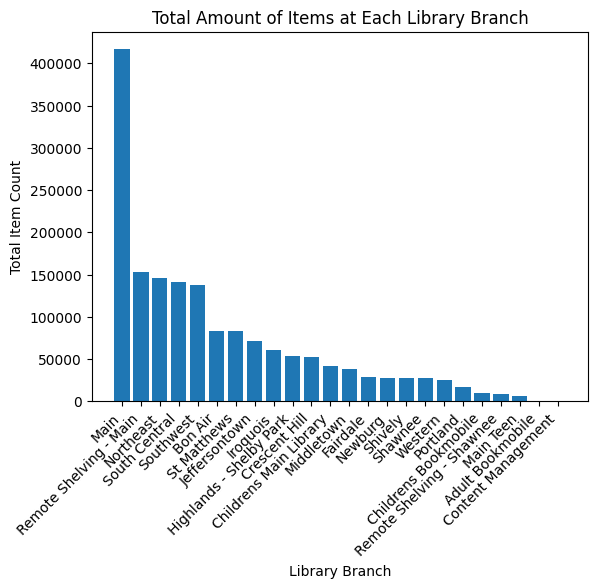

In [ ]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

Combining Locations to get a proper total (i.e. 'Remote Shelving-Shawnee' to 'Shawnee')

In [ ]:
df['ItemLocation'] = df['ItemLocation'].replace('Remote Shelving - Shawnee', 'Shawnee')

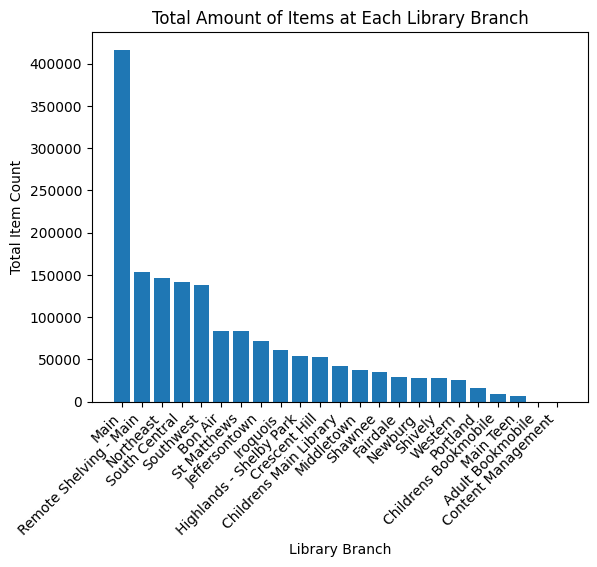

In [ ]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

In [ ]:
df['ItemLocation'] = df['ItemLocation'].replace('Childrens Bookmobile', 'Bookmobile')
df['ItemLocation'] = df['ItemLocation'].replace('Adult Bookmobile', 'Bookmobile')

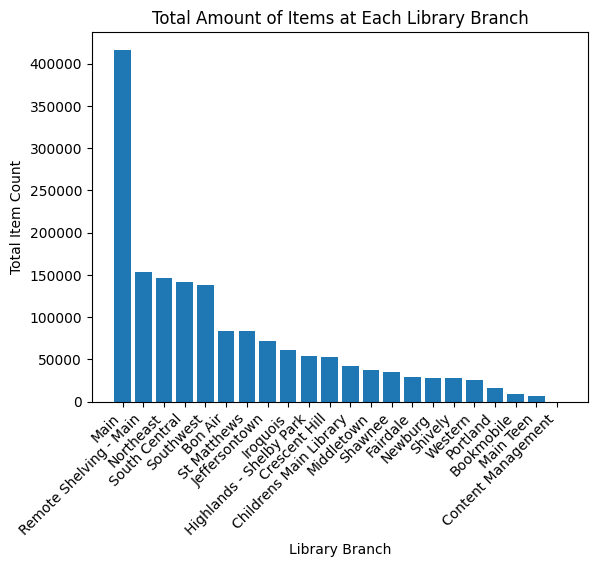

In [ ]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

In [ ]:
df['ItemLocation'] = df['ItemLocation'].replace(['Remote Shelving - Main', 'Childrens Main Library', 'Main Teen'], 'Main')

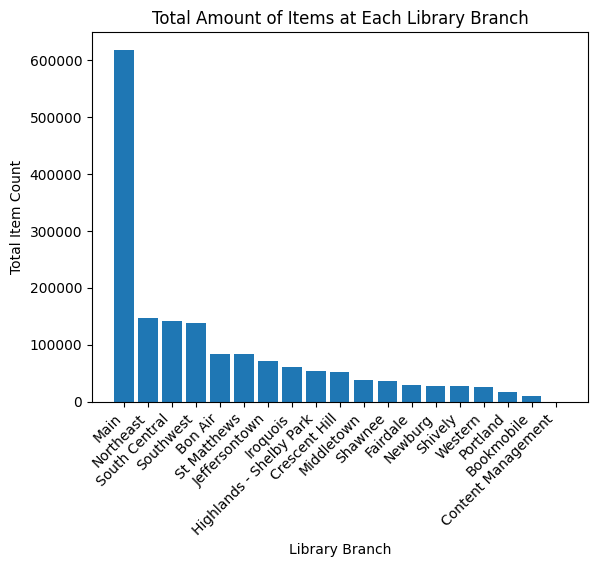

In [ ]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

Removing 'Main' as it has a disproportionate amount of item compared to the other branches

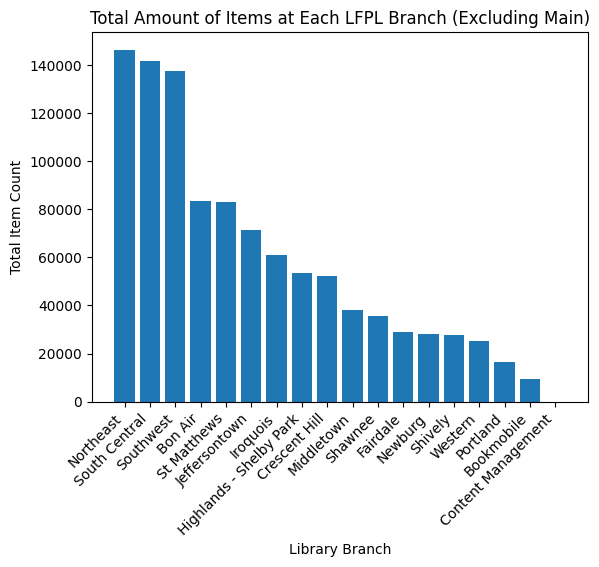

In [ ]:
item_count_non_Main = (
    df[df['ItemLocation'] != 'Main']['ItemLocation']
    .value_counts())


plt.bar(item_count_non_Main.index, item_count_non_Main.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each LFPL Branch (Excluding Main)')

plt.show()

In [ ]:
df[df['ItemLocation'] == 'Content Management'].value_counts()

BibNum  Title                                                                             Author                ISBN             PublicationYear  ItemType  ItemCollection   ItemLocation        ItemPrice
569591  The Penguin guide to compact discs and DVDs : Yearbook                            March, Ivan.          9780141027234.0  2006             Book      Adult Reference  Content Management  22.00        1
807930  Effective phrases for performance appraisals : a guide to successful evaluations  Neal, James E. Jr.    9781882423125.0  2009             Book      Adult Reference  Content Management  12.95        1
811188  Introducing RDA : a guide to the basics                                           Oliver, Chris, 1951-  9780838935941.0  2010             Book      Adult Reference  Content Management  45.00        1
Name: count, dtype: int64

Replacing 'Content Management' location with standard 'Main' as it only applies to 3 items 

In [ ]:
df['ItemLocation'] = df['ItemLocation'].replace('Content Management', 'Main')

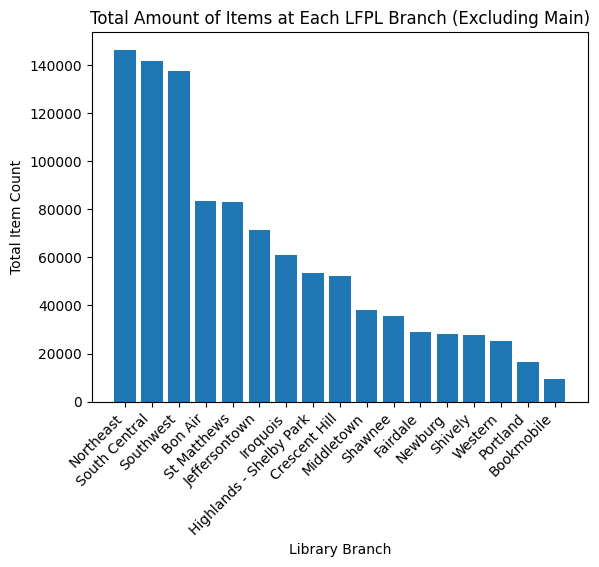

In [ ]:
item_count_non_Main = (
    df[df['ItemLocation'] != 'Main']['ItemLocation']
    .value_counts())


plt.bar(item_count_non_Main.index, item_count_non_Main.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each LFPL Branch (Excluding Main)')

plt.show()

I wanted to see if there were areas in Louisville that were underserved in regards to libraries. At first glance, one might think the west side of Louisville is compared to the east or south. It would be helpful to next look at the amount of libraries in an area as some libraries like Fairdale seem to be responsible for a much larger area than Western, so are they really comparable.

In [ ]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

ItemLocation
Main                       617888
Northeast                  146500
South Central              141712
Southwest                  137503
Bon Air                     83684
St Matthews                 83030
Jeffersontown               71236
Iroquois                    61111
Highlands - Shelby Park     53447
Crescent Hill               52317
Middletown                  37940
Shawnee                     35512
Fairdale                    29005
Newburg                     27924
Shively                     27625
Western                     25123
Portland                    16462
Bookmobile                   9535
Name: count, dtype: int64

In [ ]:
libraries = pd.DataFrame({
    "library_name": [
        "Northeast", "South Central", "Southwest", "Bon Air", "St. Matthews", "Jeffersontown", "Iroquois", "Highlands", "Crescent Hill", "Middletown", "Shawnee", "Fairdale", "Newburg", "Shively", "Western", "Portland"
    ],
    "items": [
        146500, 141712, 137502, 83684, 83030, 71236, 61111,
        53447, 52317, 37940, 35512, 29005, 27924, 27625, 25123, 16462
    ],
    "latitude": [  
        38.2684,  # Northeast
        38.1447,  # South Central
        38.1700,  # Southwest
        38.2152,  # Bon Air
        38.2470,  # St Matthews
        38.1860,  # Jeffersontown
        38.1827,  # Iroquois
        38.2348,  # Highlands - Shelby Park
        38.2545,  # Crescent Hill
        38.2189,  # Middletown
        38.2529,  # Shawnee
        38.1079,  # Fairdale
        38.2219,  # Newburg
        38.2005,  # Shively
        38.2516,  # Western
        38.2692   # Portland
    ],
    "longitude": [
        -85.5763,  # Northeast
        -85.6756,  # South Central
        -85.7935,  # Southwest
        -85.6552,  # Bon Air
        -85.6586,  # St Matthews
        -85.5610,  # Jeffersontown
        -85.7715,  # Iroquois
        -85.7182,  # Highlands - Shelby Park
        -85.6911,  # Crescent Hill
        -85.5254,  # Middletown
        -85.8107,  # Shawnee
        -85.7610,  # Fairdale
        -85.7561,  # Newburg
        -85.8240,  # Shively
        -85.7764,  # Western
        -85.8110   # Portland
    ]
})


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(libraries["longitude"], libraries["latitude"])]

gdf_libraries = gpd.GeoDataFrame(libraries, geometry=geometry, crs="EPSG:4326")


In [ ]:
zipcodes = gpd.read_file("tl_2020_us_zcta520/tl_2020_us_zcta520.shp")


In [ ]:
louisville_zips = zipcodes[zipcodes["ZCTA5CE20"].isin([
    "40202","40203","40204","40205","40206","40207","40208","40209",
    "40210","40211","40212","40213","40214","40215","40216","40217",
    "40218","40219","40220","40222","40223","40228","40229","40241",
    "40242","40243","40245","40258","40272","40291","40299"
])]


In [ ]:
louisville_zips = louisville_zips.to_crs(gdf_libraries.crs)


FileNotFoundError: [Errno 2] No such file or directory: '../plots/TotalItemsbyLibraryBranchExceptMainPinMap.png'

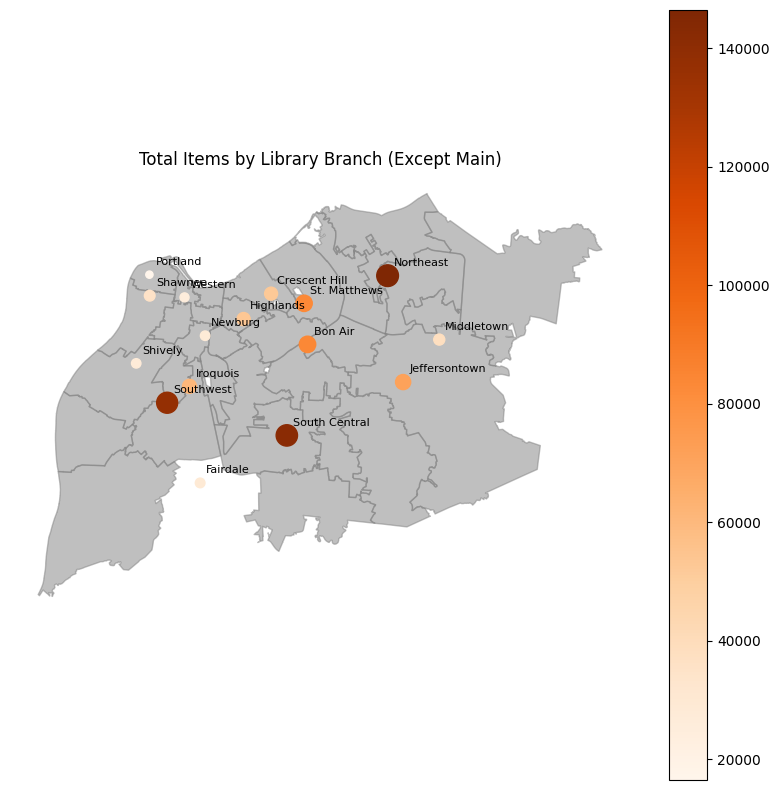

In [ ]:
ax = louisville_zips.plot(
    figsize=(10, 10),
    color="grey",
    edgecolor="grey",
    alpha=0.5
)

ax = gdf_libraries.plot(
    ax=ax,
    column="items",
    cmap="Oranges",
    legend=True,
    markersize=gdf_libraries["items"] / 600
)

ax.set_title("Total Items by Library Branch (Except Main)")
ax.axis("off")

for x, y, name in zip(
    gdf_libraries.geometry.x,
    gdf_libraries.geometry.y,
    gdf_libraries["library_name"]
):
    ax.text(
        x + 0.006,  # horizontal offset
        y + 0.006,  # vertical offset
        name,
        fontsize=8,
        color="black",
        ha="left",
        va="bottom"
    )

plt.savefig('../plots/TotalItemsbyLibraryBranchExceptMainPinMap.png')



In [ ]:
df.ItemType.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

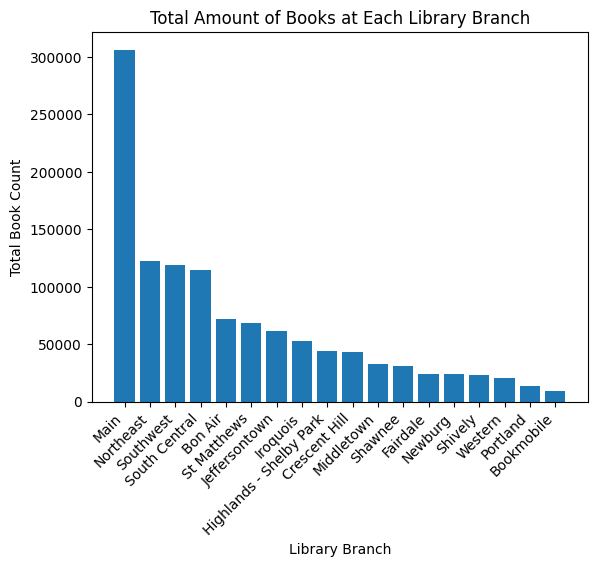

In [ ]:
book_itemtype = df[df['ItemType'] == 'Book']
book_count = book_itemtype.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
book_count

plt.bar(book_count.index, book_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Book Count')
plt.title('Total Amount of Books at Each Library Branch')

plt.show()



In [ ]:
ebook_items = df[df['ItemType'].isin(['Ebook', 'Eaudiobook', 'Emagazine'])]

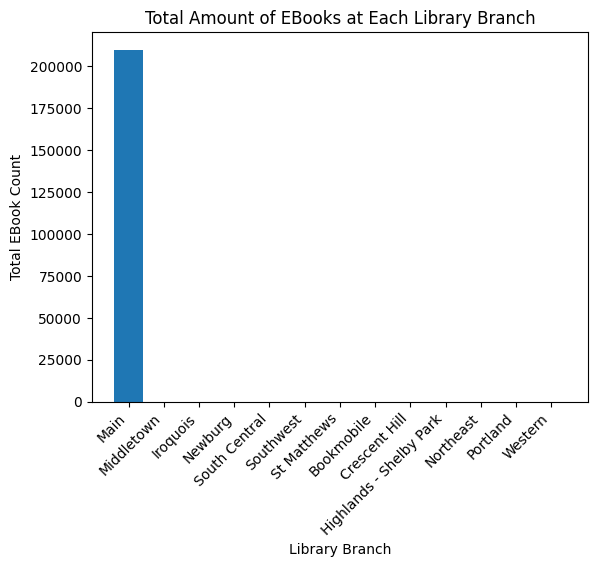

In [ ]:
ebook_count = ebook_items.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
ebook_count

plt.bar(ebook_count.index, ebook_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total EBook Count')
plt.title('Total Amount of EBooks at Each Library Branch')

plt.show()

In [ ]:
ebook_len = len(ebook_items.value_counts())

In [ ]:
book_len = len(df[df['ItemType'] == 'Book'].value_counts())

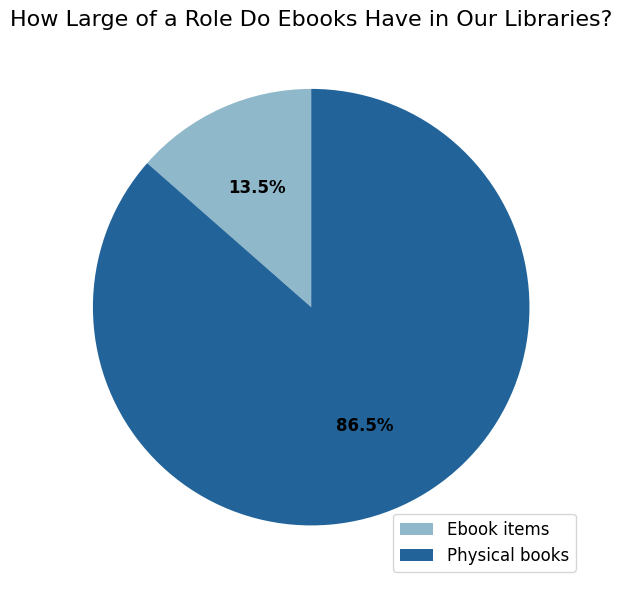

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(
    [ebook_len, book_len],
    labels=None,
    startangle=90,
    colors=["#8fb8caff", "#22649aff"],
    autopct='%1.1f%%',
    textprops={'fontsize' : 12, 'weight': 'bold'})

plt.title('How Large of a Role Do Ebooks Have in Our Libraries?', fontsize=16)
plt.legend(
    labels = ['Ebook items', 'Physical books'], fontsize=12,
    loc='lower right'
)

plt.tight_layout()
plt.show()

As an avid user of the Libby app, it would be interesting to see how this has grown or is growing.

In [ ]:
df['ItemCollection'].value_counts().sort_values(ascending=True).head(10)

ItemCollection
Telescope                            6
Teen Reference                       9
Launchpad                           10
Listening Device                    16
Digital Camera                      18
College Shop                        19
Telereference                       26
Teen Non-Fiction Audiobook          33
Big Book                            56
Children's Non-Fiction Paperback    70
Name: count, dtype: int64

In [ ]:
#Look over quantitative data
df['ItemPrice'].describe().apply(lambda x: f'${x:,.2f}')

ValueError: Unknown format code 'f' for object of type 'str'

In [ ]:
df['ItemPrice'] = df['ItemPrice'].apply(lambda x: f'${x:,.2f}')

In [ ]:
df[df['ItemPrice'] == 0.0]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice


In [ ]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9780071605878.0,2009,Book,Adult Non-Fiction,Main,$25.95
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9780071478939.0,2007,Book,ELL Collection,South Central,$20.00
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,$19.99
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9780071496421.0,2008,Book,ELL Collection,South Central,$20.00
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,$19.99


In [ ]:
df['ISBN'][0]

'9780071605878.0'

In [ ]:
type(df['ISBN'][0])

str

In [ ]:
odd_pub_yr = df[df['PublicationYear'] > 2025]
odd_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
30527,2344805,The Shift,"Johnson, Tory",9780316286626.0,2050,Ebook,Electronic,Main,$0.00
299609,407990,Residual life assessment of major light water ...,NaN,nan,9999,Book,Government Documents,Main,$75.00
725313,820258,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",nan,9999,Book,Mystery,Main,$14.95
731136,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731137,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731138,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731139,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731140,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731141,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
756230,2289915,Everything Will Be Okay,"Perino, Dana",9781538708873.0,2099,Ebook,Electronic,Main,$0.00


In [ ]:
df['PublicationYear'] = df['PublicationYear'].replace(2109, 2019)

In [ ]:
df.loc[1551094]

BibNum                                       2230396
Title              Love and death among the cheetahs
Author                                   Bowen, Rhys
ISBN                                 9780451492845.0
PublicationYear                                 2019
ItemType                                        Book
ItemCollection                               Mystery
ItemLocation                           Jeffersontown
ItemPrice                                     $13.75
Name: 1551094, dtype: object

In [ ]:
odd_pub_yr = df[df['PublicationYear'] > 2025]
odd_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
30527,2344805,The Shift,"Johnson, Tory",9780316286626.0,2050,Ebook,Electronic,Main,$0.00
299609,407990,Residual life assessment of major light water ...,NaN,nan,9999,Book,Government Documents,Main,$75.00
725313,820258,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",nan,9999,Book,Mystery,Main,$14.95
731136,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731137,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731138,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731139,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731140,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731141,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
756230,2289915,Everything Will Be Okay,"Perino, Dana",9781538708873.0,2099,Ebook,Electronic,Main,$0.00


In [ ]:
df.loc[725313, 'PublicationYear'] = 1928
df.loc[725313]

BibNum                                                   820258
Title              The Greene murder case : a Philo Vance story
Author                                          Van Dine, S. S.
ISBN                                                        nan
PublicationYear                                            1928
ItemType                                                   Book
ItemCollection                                          Mystery
ItemLocation                                               Main
ItemPrice                                                $14.95
Name: 725313, dtype: object

In [ ]:
odd_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
30527,2344805,The Shift,"Johnson, Tory",9780316286626.0,2050,Ebook,Electronic,Main,$0.00
299609,407990,Residual life assessment of major light water ...,NaN,nan,9999,Book,Government Documents,Main,$75.00
725313,820258,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",nan,9999,Book,Mystery,Main,$14.95
731136,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731137,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731138,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731139,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731140,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
731141,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",nan,5124,Serial,Kentucky History,Main,$2.00
756230,2289915,Everything Will Be Okay,"Perino, Dana",9781538708873.0,2099,Ebook,Electronic,Main,$0.00
